# S2Sharp Example

Sentinel-2 sharpening using a reduced-rank method on an AVIRIS-simulated dataset.

**Reference:** Sentinel-2 Sharpening Using a Reduced-Rank Method, M. Ulfarsson et al., IEEE Transactions on Geoscience and Remote Sensing, 2019.

In [1]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

from s2sharp import s2sharp
from s2sharp.constants import BAND_NAMES, DOWNSAMPLE_FACTORS

## 1. Load Data

In [2]:
data = scipy.io.loadmat('../Data/Aviris_cell_3.mat', squeeze_me=True, simplify_cells=True)

Yim = data['Yim']
bands = [Yim[i].astype(np.float64) for i in range(len(Yim))]
Xm_im = data['Xm_im'].astype(np.float64)

print(f"Number of bands: {len(bands)}")
print(f"Ground truth shape: {Xm_im.shape}")
print()
for i, name in enumerate(BAND_NAMES):
    print(f"  {name}: {bands[i].shape}  (d={DOWNSAMPLE_FACTORS[i]})")

Number of bands: 12
Ground truth shape: (408, 408, 12)

  B1: (68, 68)  (d=6)
  B2: (408, 408)  (d=1)
  B3: (408, 408)  (d=1)
  B4: (408, 408)  (d=1)
  B5: (204, 204)  (d=2)
  B6: (204, 204)  (d=2)
  B7: (204, 204)  (d=2)
  B8: (408, 408)  (d=1)
  B8A: (204, 204)  (d=2)
  B9: (68, 68)  (d=6)
  B11: (204, 204)  (d=2)
  B12: (204, 204)  (d=2)


## 2. Algorithm Parameters

These match the MATLAB `example.m` settings.

In [3]:
r = 8        # subspace dimension / rank
lam = 1.8998e-04  # regularization parameter
q = np.array([1, 0.3851, 6.9039, 19.9581, 47.8967, 27.5518, 2.7100, 34.8689])
ni = 10      # number of CD iterations

## 3. Run S2Sharp

In [4]:
result = s2sharp(
    bands,
    ground_truth=Xm_im,
    r=r,
    lam=lam,
    q=q,
    cd_iter=ni,
)

print(f"Completed in {result.Time:.1f} s")
print(f"Output image shape: {result.image.shape}")

Completed in 107.4 s
Output image shape: (404, 404, 12)


## 4. Results Summary

In [5]:
# Indices for non-10m bands (0-based)
sre_bands = [0, 4, 5, 6, 8, 9, 10, 11]
sre_band_names = ["B1", "B5", "B6", "B7", "B8A", "B9", "B11", "B12"]

S2sharp_SRE = result.SRE[-1][sre_bands]
S2sharp_SAM = result.SAMm[-1]
S2sharp_aSRE = np.mean(S2sharp_SRE)
S2sharp_RMSE = result.RMSE[-1]
S2sharp_aSSIM = result.aSSIM[-1]
S2sharp_ERGAS_60m = result.ERGAS_60m[-1]
S2sharp_ERGAS_20m = result.ERGAS_20m[-1]

print(f"S2sharp: Best lambda = {lam}")
print(f"S2sharp: SAM        = {S2sharp_SAM:.4f}")
print(f"Average SRE          = {S2sharp_aSRE:.4f}")
print(f"S2sharp aSSIM        = {S2sharp_aSSIM:.4f}")
print(f"S2sharp RMSE         = {S2sharp_RMSE:.6f}")
print(f"S2sharp ERGAS 20m    = {S2sharp_ERGAS_20m:.4f}")
print(f"S2sharp ERGAS 60m    = {S2sharp_ERGAS_60m:.4f}")
print(f"S2sharp time         = {result.Time:.2f} s")
print()
print("Per-band SRE (dB):")
print("  ".join(f"{n:>6s}" for n in sre_band_names))
print("  ".join(f"{v:6.2f}" for v in S2sharp_SRE))

S2sharp: Best lambda = 0.00018998
S2sharp: SAM        = 0.8717
Average SRE          = 36.6129
S2sharp aSSIM        = 0.9908
S2sharp RMSE         = 0.410118
S2sharp ERGAS 20m    = 1.3156
S2sharp ERGAS 60m    = 0.4531
S2sharp time         = 107.38 s

Per-band SRE (dB):
    B1      B5      B6      B7     B8A      B9     B11     B12
 31.43   38.25   40.58   44.41   46.16   36.82   27.99   27.26


## 5. Convergence

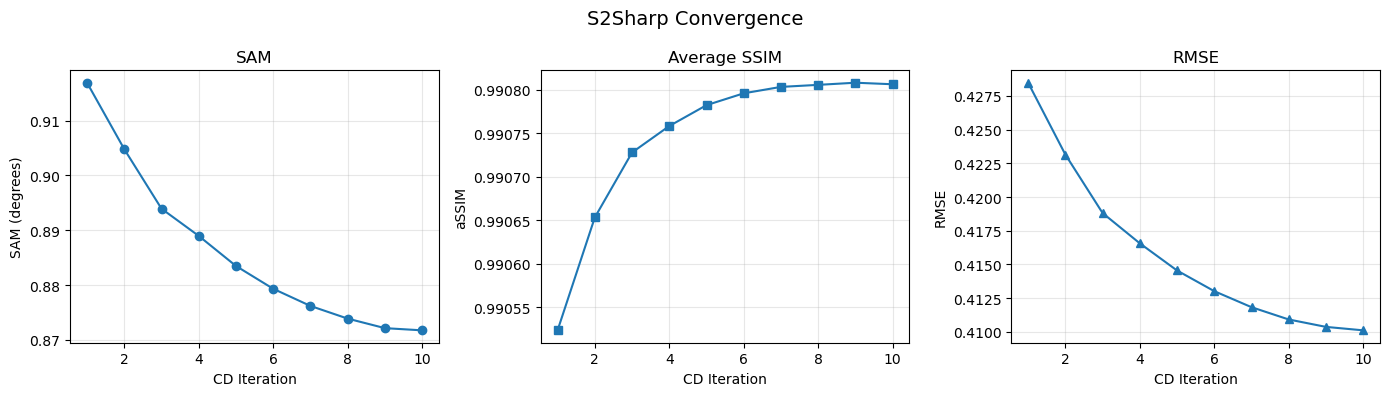

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

iters = range(1, len(result.SAMm) + 1)

axes[0].plot(iters, result.SAMm, 'o-')
axes[0].set_xlabel('CD Iteration')
axes[0].set_ylabel('SAM (degrees)')
axes[0].set_title('SAM')
axes[0].grid(True, alpha=0.3)

axes[1].plot(iters, result.aSSIM, 's-')
axes[1].set_xlabel('CD Iteration')
axes[1].set_ylabel('aSSIM')
axes[1].set_title('Average SSIM')
axes[1].grid(True, alpha=0.3)

axes[2].plot(iters, result.RMSE, '^-')
axes[2].set_xlabel('CD Iteration')
axes[2].set_ylabel('RMSE')
axes[2].set_title('RMSE')
axes[2].grid(True, alpha=0.3)

fig.suptitle('S2Sharp Convergence', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Per-Band SRE

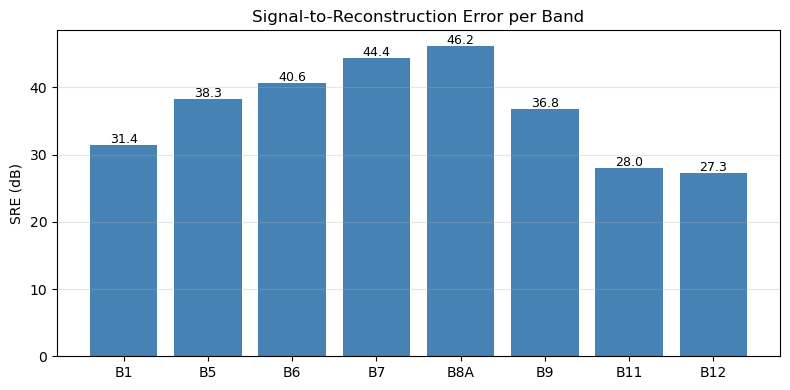

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(sre_band_names, S2sharp_SRE, color='steelblue')
ax.set_ylabel('SRE (dB)')
ax.set_title('Signal-to-Reconstruction Error per Band')
ax.grid(True, axis='y', alpha=0.3)
for i, v in enumerate(S2sharp_SRE):
    ax.text(i, v + 0.3, f"{v:.1f}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 7. Visual Comparison

RGB composite using B4 (Red), B3 (Green), B2 (Blue).

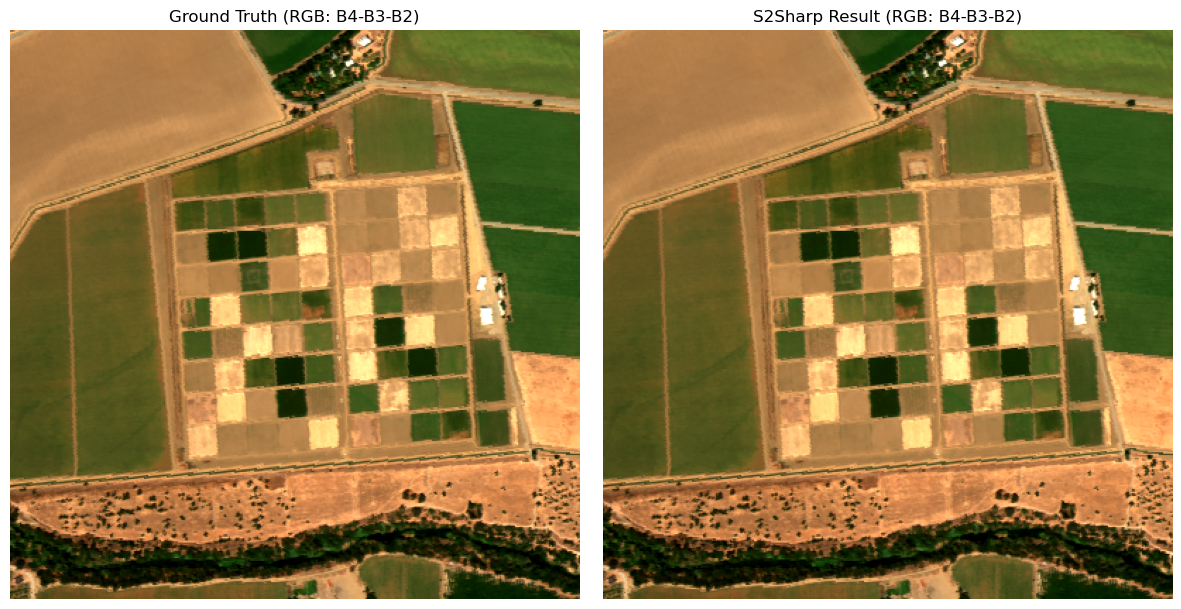

In [8]:
border = 2
gt_crop = Xm_im[border:-border, border:-border, :]

# RGB from B4(idx 3), B3(idx 2), B2(idx 1)
rgb_bands = [3, 2, 1]

def to_rgb(img, bands_idx):
    rgb = np.stack([img[:, :, b] for b in bands_idx], axis=-1)
    lo, hi = np.percentile(rgb, [2, 98])
    rgb = np.clip((rgb - lo) / (hi - lo), 0, 1)
    return rgb

rgb_gt = to_rgb(gt_crop, rgb_bands)
rgb_est = to_rgb(result.image, rgb_bands)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(rgb_gt)
axes[0].set_title('Ground Truth (RGB: B4-B3-B2)')
axes[0].axis('off')

axes[1].imshow(rgb_est)
axes[1].set_title('S2Sharp Result (RGB: B4-B3-B2)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 8. Preconditioner Benchmark

Compare standard CG vs preconditioned CG (PCG) in terms of iteration count and wall-clock time.

In [9]:
import time

# --- Standard CG (no preconditioner) ---
t0 = time.perf_counter()
result_cg = s2sharp(
    bands, ground_truth=Xm_im, r=r, lam=lam, q=q, cd_iter=ni,
    precondition=False,
)
t_cg = time.perf_counter() - t0

# --- Preconditioned CG ---
t0 = time.perf_counter()
result_pcg = s2sharp(
    bands, ground_truth=Xm_im, r=r, lam=lam, q=q, cd_iter=ni,
    precondition=True,
)
t_pcg = time.perf_counter() - t0

# --- Print comparison table ---
cg_iters = result_cg.cg_iterations
pcg_iters = result_pcg.cg_iterations

print(f"{'CD iter':<10} {'CG':<10} {'PCG':<10} {'Ratio':<10}")
print("-" * 40)
for i, (c, p) in enumerate(zip(cg_iters, pcg_iters), 1):
    ratio = p / c if c > 0 else float('nan')
    print(f"{i:<10} {c:<10} {p:<10} {ratio:<10.3f}")

total_cg = sum(cg_iters)
total_pcg = sum(pcg_iters)
print("-" * 40)
print(f"{'Total':<10} {total_cg:<10} {total_pcg:<10} {total_pcg/total_cg:<10.3f}")

print(f"\n{'Metric':<20} {'CG':<15} {'PCG':<15}")
print("-" * 50)
print(f"{'Wall-clock (s)':<20} {t_cg:<15.1f} {t_pcg:<15.1f}")
print(f"{'Speedup':<20} {'1.00x':<15} {f'{t_cg/t_pcg:.2f}x':<15}")
print(f"{'SAM':<20} {result_cg.SAMm[-1]:<15.4f} {result_pcg.SAMm[-1]:<15.4f}")
print(f"{'aSSIM':<20} {result_cg.aSSIM[-1]:<15.4f} {result_pcg.aSSIM[-1]:<15.4f}")
print(f"{'RMSE':<20} {result_cg.RMSE[-1]:<15.6f} {result_pcg.RMSE[-1]:<15.6f}")

CD iter    CG         PCG        Ratio     
----------------------------------------
1          24         11         0.458     
2          3          2          0.667     
3          3          2          0.667     
4          2          2          1.000     
5          2          2          1.000     
6          2          1          0.500     
7          2          1          0.500     
8          2          1          0.500     
9          1          1          1.000     
10         1          1          1.000     
----------------------------------------
Total      42         24         0.571     

Metric               CG              PCG            
--------------------------------------------------
Wall-clock (s)       87.1            67.3           
Speedup              1.00x           1.30x          
SAM                  0.8717          0.8590         
aSSIM                0.9908          0.9909         
RMSE                 0.410118        0.399815       
